<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/ML_Exp01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Upload Dataset**
This cell allows the user to manually upload the `healthcare_dataset.csv` file into Colab and loads it into a Pandas DataFrame for further processing. The first few rows are displayed to verify the upload.


In [ ]:
from google.colab import files
import pandas as pd

# Upload the file manually
uploaded = files.upload()

# Load the CSV (adjust name if different)
df = pd.read_csv('healthcare_dataset.csv')
df.head()

Saving healthcare_dataset.csv to healthcare_dataset.csv


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


# **2. Data Cleaning**
This cell performs basic data cleaning tasks including:
- Checking for missing values
- Removing duplicates and dropping rows with missing values
- Resetting the index
- Standardizing text columns
- Cleaning hospital names
- Rounding billing amounts
- Fixing gender mismatches based on patient names

The cleaned dataset is displayed for verification.


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('healthcare_dataset.csv')

# ===================== CLEANING STEPS =====================

# 1. Check for missing values
print("Missing Values:\n", df.isnull().sum())

# 2. Drop duplicate rows
df.drop_duplicates(inplace=True)

# 3. Drop rows with missing values
df.dropna(inplace=True)

# 4. Reset the index
df.reset_index(drop=True, inplace=True)

# 5. Standardize text columns to proper case
text_columns = ['Name', 'Doctor', 'Hospital', 'Insurance Provider', 'Medication', 'Test Results']
for col in text_columns:
    if col in df.columns:   # ✅ avoids KeyError if any column is missing
        df[col] = df[col].str.strip().str.title()

# 6. Remove trailing commas in hospital names
if 'Hospital' in df.columns:
    df['Hospital'] = df['Hospital'].str.replace(r',$', '', regex=True)

# 7. Round billing amount to 2 decimal places
if 'Billing Amount' in df.columns:
    df['Billing Amount'] = df['Billing Amount'].round(2)

# 8. Fix gender mismatches based on name
if 'Name' in df.columns and 'Gender' in df.columns:
    male_names = ['Bobby Jackson', 'Leslie Terry', 'Danny Smith', 'Andrew Watts']
    female_names = ['Adrienne Bell', 'Emily Johnson']
    df['Gender'] = df.apply(
        lambda row: 'Male' if row['Name'] in male_names else (
            'Female' if row['Name'] in female_names else row['Gender']
        ), axis=1
    )

# ===================== FINAL DISPLAY =====================
print(df[['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
          'Date of Admission', 'Discharge Date', 'Doctor', 'Hospital',
          'Insurance Provider', 'Billing Amount', 'Room Number',
          'Admission Type', 'Medication', 'Test Results']])

Missing Values:
 Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64
                    Name  Age  Gender Blood Type Medical Condition  \
0          Bobby Jackson   30    Male         B-            Cancer   
1           Leslie Terry   62    Male         A+           Obesity   
2            Danny Smith   76    Male         A-           Obesity   
3           Andrew Watts   28    Male         O+          Diabetes   
4          Adrienne Bell   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
54961  Elizabeth Jackson   42  Female         O+            Asthma   
54962         Kyle Perez   61  Female        AB-  

# **3. Date Feature Engineering**
This cell converts date columns into datetime format and extracts `Year`, `Month`, and `Day` from the `Date of Admission`. It also calculates the `Length of Stay` in days for each patient, filling missing or negative values with 0 to avoid errors.
# **4. Create Billing per Day Feature**
This cell creates a new feature, `Billing_per_day`, which represents the daily billing amount by dividing `Billing Amount` by `Length of Stay`. Any division by zero is safely handled. The first 10 rows are displayed to verify the new feature.


In [ ]:
# Convert date columns to datetime
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')

# Extract year, month, day
df['Year'] = df['Date of Admission'].dt.year
df['Month'] = df['Date of Admission'].dt.month
df['Day'] = df['Date of Admission'].dt.day

# Calculate Length of Stay safely
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Length of Stay'] = df['Length of Stay'].fillna(0).astype(int)  # ✅ avoids NaN errors

df[['Date of Admission', 'Discharge Date', 'Year', 'Month', 'Day', 'Length of Stay']].head()

,Date of Admission,Discharge Date,Year,Month,Day,Length of Stay
0,2024-01-31,2024-02-02,2024,1,31,2
1,2019-08-20,2019-08-26,2019,8,20,6
2,2022-09-22,2022-10-07,2022,9,22,15
3,2020-11-18,2020-12-18,2020,11,18,30
4,2022-09-19,2022-10-09,2022,9,19,20


In [ ]:
# Create Billing Per Day feature safely
df['Billing_per_day'] = df['Billing Amount'] / df['Length of Stay'].replace(0, 1)

df[['Billing Amount', 'Length of Stay', 'Billing_per_day']].head(10)

,Billing Amount,Length of Stay,Billing_per_day
0,18856.28,2,9428.140000
1,33643.33,6,5607.221667
2,27955.10,15,1863.673333
3,37909.78,30,1263.659333
4,14238.32,20,711.916000
5,48145.11,4,12036.277500
6,19580.87,12,1631.739167
7,45820.46,10,4582.046000
8,50119.22,13,3855.324615
9,19784.63,30,659.487667


# **5. Normalization of Numeric Features**
This cell applies **L1 and L2 normalization** to numeric columns (`Age`, `Billing Amount`, `Length of Stay`, `Billing_per_day`). This scales the data so that it is suitable for models sensitive to magnitude differences between features. Both normalized datasets are displayed.


In [ ]:
from sklearn.preprocessing import Normalizer

# Make sure required columns exist before normalization
required_cols = ['Age', 'Billing Amount', 'Length of Stay', 'Billing_per_day']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise KeyError(f"These columns are missing before normalization: {missing_cols}")

# Select numeric features to normalize
features_to_normalize = required_cols

# L1 Normalization
l1_normalizer = Normalizer(norm='l1')
df_l1 = df[features_to_normalize].copy()
df_l1[features_to_normalize] = l1_normalizer.fit_transform(df_l1)

# L2 Normalization
l2_normalizer = Normalizer(norm='l2')
df_l2 = df[features_to_normalize].copy()
df_l2[features_to_normalize] = l2_normalizer.fit_transform(df_l2)

# Show L1 and L2 normalized values
print("L1 Normalized Data:")
print(df_l1.head())

print("\nL2 Normalized Data:")
print(df_l2.head())

L1 Normalized Data:
        Age  Billing Amount  Length of Stay  Billing_per_day
0  0.001059        0.665913        0.000071         0.332957
1  0.001577        0.855660        0.000153         0.142610
2  0.002541        0.934648        0.000502         0.062310
3  0.000714        0.966311        0.000765         0.032210
4  0.002864        0.948384        0.001332         0.047419

L2 Normalized Data:
        Age  Billing Amount  Length of Stay  Billing_per_day
0  0.001423        0.894426        0.000095         0.447213
1  0.001818        0.986392        0.000176         0.164399
2  0.002713        0.997781        0.000535         0.066519
3  0.000738        0.999444        0.000791         0.033315
4  0.003016        0.998747        0.001403         0.049937


# **6. L1 and L2 Regularization**
This cell trains two regression models to demonstrate **L1 (Lasso)** and **L2 (Ridge)** regularization.
- Features: `Age`, `Length of Stay`, `Billing_per_day`
- Target: `Billing Amount`

It outputs the **Mean Squared Error (MSE)** and model coefficients for both regularization techniques.

In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Select features and target
X = df[['Age', 'Length of Stay', 'Billing_per_day']]
y = df['Billing Amount']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# L1 Regularization (Lasso)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_l1 = lasso.predict(X_test)
print("L1 Regularization (Lasso):")
print("MSE:", mean_squared_error(y_test, y_pred_l1))
print("Coefficients:", lasso.coef_)

# L2 Regularization (Ridge)
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
y_pred_l2 = ridge.predict(X_test)
print("\nL2 Regularization (Ridge):")
print("MSE:", mean_squared_error(y_test, y_pred_l2))
print("Coefficients:", ridge.coef_)

L1 Regularization (Lasso):
MSE: 174078401.20737785
Coefficients: [ -1.89217402 391.41563797   1.10769409]

L2 Regularization (Ridge):
MSE: 174078402.03076404
Coefficients: [ -1.89243788 391.41751471   1.10769558]


# **7. Encoding Categorical Variables**
This cell encodes categorical variables to make them usable in machine learning models:
- One-Hot Encoding (OHE) for nominal features like `Gender`, `Blood Type`, `Admission Type`, `Insurance Provider`, `Test Results`
- Label Encoding for `Medication`

A sample of encoded features combined with numerical ones is displayed.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# One-Hot Encoding for nominal categorical features
df_encoded = pd.get_dummies(df, columns=[
    'Gender', 'Blood Type', 'Admission Type', 'Insurance Provider', 'Test Results'
])

# Label Encoding for Medication (ordinal or for ML model use)
label_enc = LabelEncoder()
df_encoded['Medication_Encoded'] = label_enc.fit_transform(df_encoded['Medication'])

# Preview a few encoded features + numerical ones
df_encoded[['Age', 'Billing Amount', 'Length of Stay', 'Billing_per_day',
            'Medication_Encoded'] +
           [col for col in df_encoded.columns if 'Gender_' in col]].head()

,Age,Billing Amount,Length of Stay,Billing_per_day,Medication_Encoded,Gender_Female,Gender_Male
0,30,18856.28,2,9428.140000,3,False,True
1,62,33643.33,6,5607.221667,1,False,True
2,76,27955.10,15,1863.673333,0,False,True
3,28,37909.78,30,1263.659333,1,False,True
4,43,14238.32,20,711.916000,4,True,False


# **8. Standardization of Numeric Features**
This cell standardizes numeric features (`Age`, `Billing Amount`, `Room Number`, `Length of Stay`, `Billing_per_day`) using **Z-score normalization** via `StandardScaler`. This ensures features have mean = 0 and variance = 1, which is useful for algorithms like PCA or gradient-based models.


In [ ]:
from sklearn.preprocessing import StandardScaler

# === List of columns to standardize ===
columns_to_standardize = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay', 'Billing_per_day']

# === Initialize scaler and apply ===
scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[columns_to_standardize] = scaler.fit_transform(df[columns_to_standardize])

# === Display standardized data ===
print(df_standardized[columns_to_standardize].head())

        Age  Billing Amount  Room Number  Length of Stay  Billing_per_day
0 -1.098427       -0.470713     0.233250       -1.558559         1.041033
1  0.533770        0.570021    -0.313520       -1.096739         0.382001
2  1.247856        0.169675    -0.834253       -0.057646        -0.263687
3 -1.200439        0.870301     1.292075        1.674178        -0.367178
4 -0.435347       -0.795732     1.361506        0.519629        -0.462343


# **9. Variable Transformations**
This cell applies multiple transformations to reduce skewness and improve model performance:
- Log transformation (`log`)
- Square root transformation (`sqrt`)
- Yeo-Johnson transformation (handles zero and negative values)

The transformed variables are displayed for verification.


In [ ]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

# Apply log transformation (add small epsilon to avoid log(0))
epsilon = 1e-5
df['Billing Amount_log'] = np.log(df['Billing Amount'] + epsilon)
df['Billing_per_day_log'] = np.log(df['Billing_per_day'] + epsilon)

# Apply square root transformation
df['Billing Amount_sqrt'] = np.sqrt(df['Billing Amount'])
df['Billing_per_day_sqrt'] = np.sqrt(df['Billing_per_day'])

# Apply Yeo-Johnson transformation (can handle 0 and negative values)
pt = PowerTransformer(method='yeo-johnson')
df[['Billing Amount_yeojohnson', 'Billing_per_day_yeojohnson']] = pt.fit_transform(
    df[['Billing Amount', 'Billing_per_day']]
)

# Preview transformed variables
print(df[['Billing Amount', 'Billing_per_day',
          'Billing Amount_log', 'Billing_per_day_log',
          'Billing Amount_sqrt', 'Billing_per_day_sqrt',
          'Billing Amount_yeojohnson', 'Billing_per_day_yeojohnson']].head())

   Billing Amount  Billing_per_day  Billing Amount_log  Billing_per_day_log  \
0        18856.28      9428.140000            9.844601             9.151454   
1        33643.33      5607.221667           10.423570             8.631811   
2        27955.10      1863.673333           10.238355             7.530305   
3        37909.78      1263.659333           10.542964             7.141767   
4        14238.32       711.916000            9.563692             6.567960   

   Billing Amount_sqrt  Billing_per_day_sqrt  Billing Amount_yeojohnson  \
0           137.318171             97.098610                  -0.406746   
1           183.421182             74.881384                   0.596996   
2           167.197787             43.170283                   0.223123   
3           194.704340             35.547986                   0.869707   
4           119.324432             26.681754                  -0.747365   

   Billing_per_day_yeojohnson  
0                    1.392170  
1         

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


# **10. Outlier Handling (Capping/Winsorization)**
This cell reduces the influence of extreme values by capping numeric columns (`Age`, `Billing Amount`, `Length of Stay`, `Billing_per_day`) to 1.5×IQR boundaries. This prevents extreme values from skewing the model while retaining most of the data.


In [ ]:
import numpy as np

def cap_outliers(data, column):
    """Replaces outliers with the 1.5*IQR boundaries."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values
    data[column] = np.where(data[column] < lower_bound, lower_bound,
                            np.where(data[column] > upper_bound, upper_bound, data[column]))
    return data

# Continuous numerical columns for outlier treatment
numeric_cols = ['Age', 'Billing Amount', 'Length of Stay', 'Billing_per_day']
print(f"\nPerforming outlier capping on: {numeric_cols}")

for col in numeric_cols:
    df = cap_outliers(df, col)

print("Outlier handling complete.")


Performing outlier capping on: ['Age', 'Billing Amount', 'Length of Stay', 'Billing_per_day']
Outlier handling complete.


# **11. Exploratory Data Analysis**
This cell visualizes the data using multiple plots:
- Correlation heatmap of selected numerical features
- Boxplot of `Billing Amount` by `Admission Type`
- Histogram of `Age` distribution
- Pie chart showing the distribution of patients by `Medical Condition`
- Scatter plot of `Age` vs `Billing Amount` sampled for clarity

These visualizations help identify patterns, correlations, and distribution properties of the dataset.


                Age              Date of Admission  Billing Amount  \
count  54966.000000                          54966    54966.000000   
mean      51.535185  2021-11-01 17:35:29.505512448    25544.306260   
min       13.000000            2019-05-08 00:00:00    -2008.490000   
25%       35.000000            2020-07-28 00:00:00    13243.722500   
50%       52.000000            2021-11-02 00:00:00    25542.750000   
75%       68.000000            2023-02-03 00:00:00    37819.857500   
max       89.000000            2024-05-07 00:00:00    52764.280000   
std       19.605661                            NaN    14208.409715   

        Room Number                 Discharge Date          Year  \
count  54966.000000                          54966  54966.000000   
mean     301.124404  2021-11-17 05:34:28.202161408   2021.336499   
min      101.000000            2019-05-09 00:00:00   2019.000000   
25%      202.000000            2020-08-13 00:00:00   2020.000000   
50%      302.000000          

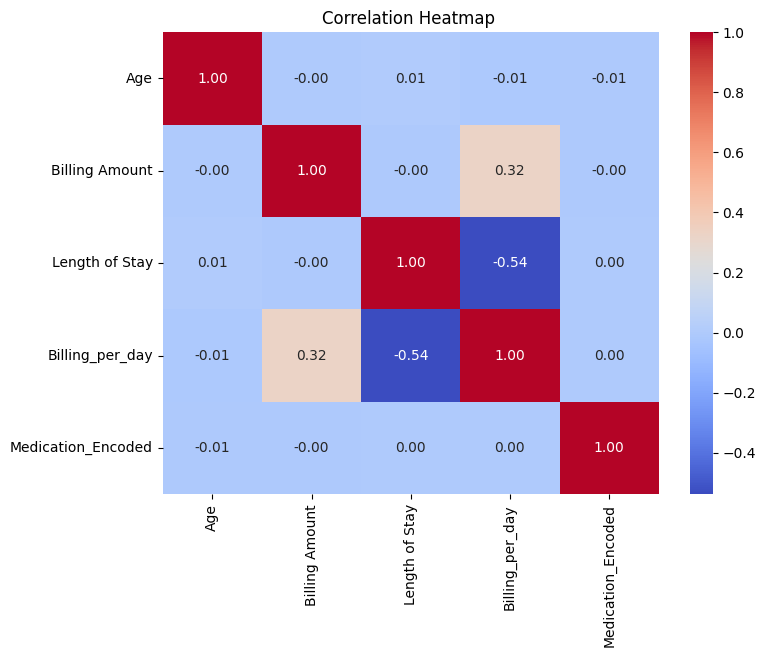

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
print(df.describe())

# Select only relevant numerical features (excluding Billing_Intensity)
corr_features = ['Age', 'Billing Amount', 'Length of Stay',
                 'Billing_per_day', 'Medication_Encoded']

# Optional: include if predicting test result
if 'Test_Normal' in df_encoded.columns:
    corr_features.append('Test_Normal')

# Compute and plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap ")
plt.show()

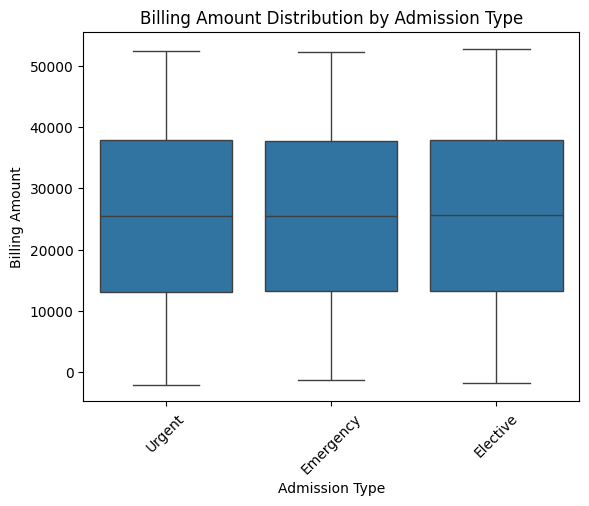

In [ ]:
sns.boxplot(x='Admission Type', y='Billing Amount', data=df)
plt.title("Billing Amount Distribution by Admission Type")
plt.xticks(rotation=45)
plt.show()

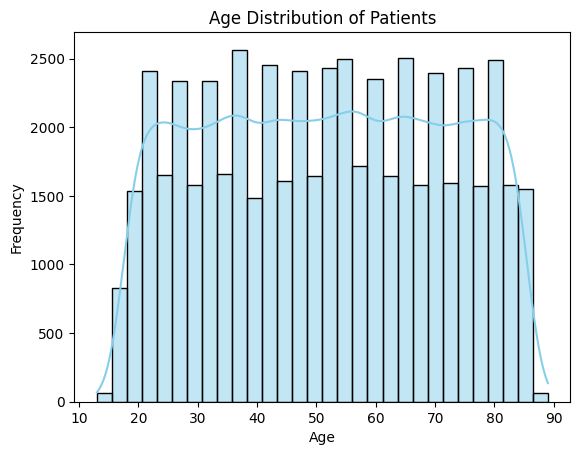

In [ ]:
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

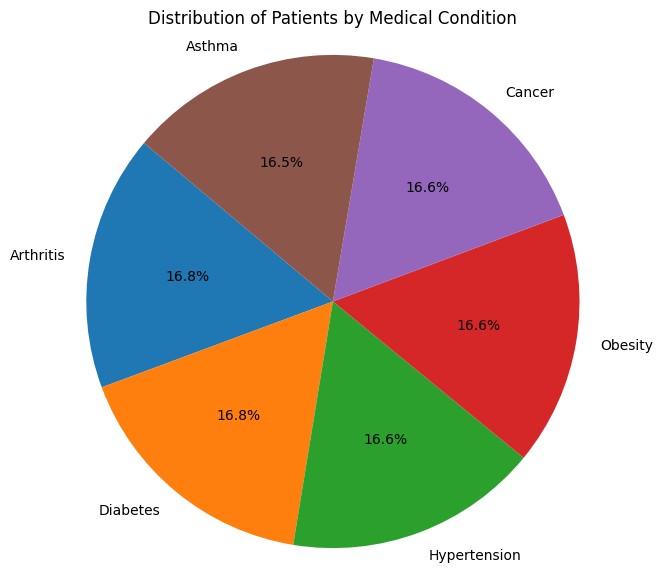

In [ ]:
# Count patients per condition
condition_counts = df['Medical Condition'].value_counts()

# Pie chart
plt.figure(figsize=(7, 7))
plt.pie(condition_counts, labels=condition_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Patients by Medical Condition")
plt.axis('equal')
plt.show()

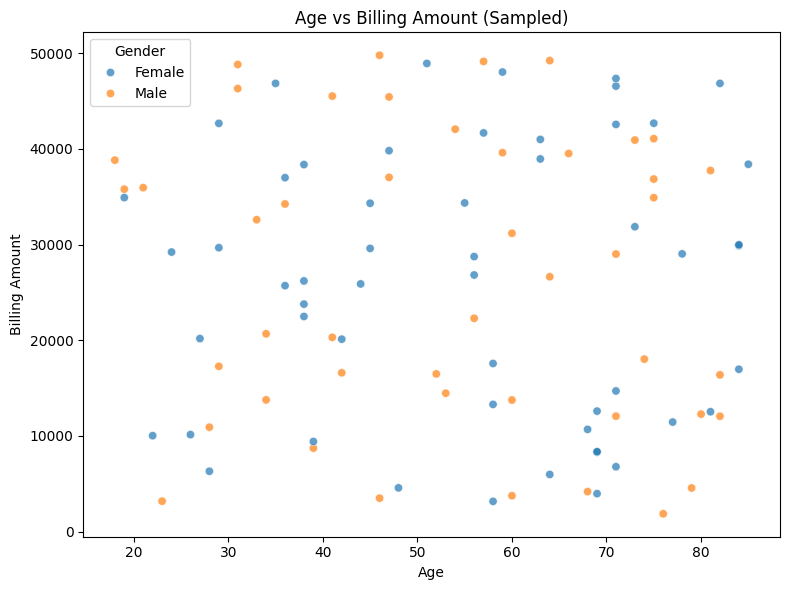

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 300 random points for cleaner scatter
df_sample = df.sample(n=100, random_state=42)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x='Age', y='Billing Amount', hue='Gender', alpha=0.7)
plt.title("Age vs Billing Amount (Sampled)")
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()